# Random Forest Classifyer

In [2]:
# setup

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
 
from sklearn.datasets import fetch_openml
from sklearn.model_selection import (StratifiedKFold, cross_val_score, cross_val_predict)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix)
 
RANDOM_STATE = 42  



In [3]:
# daten laden

data = fetch_openml(
    data_id=42742,
    as_frame=True,
    parser="auto"
)

X = data.data.copy()
y = data.target.astype(int)

# id muss nicht gedropt werden, da im open-ml datensatz nicht vorhanden; 
# sicherheitshalber assert
assert "id" not in X.columns

print("Form von X:", X.shape)
print("\nKlassenverteilung:")
print(y.value_counts(normalize=True).sort_index())



Form von X: (595212, 57)

Klassenverteilung:
target
0    0.963552
1    0.036448
Name: proportion, dtype: float64


In [9]:
# Spaltentypen bestimmen

categorical_cols = [
    c for c in X.columns
    if c.endswith("_cat")
]

numeric_cols = [
    c for c in X.columns
    if c not in categorical_cols
]

print(f"Kategoriale Features:       {len(categorical_cols)}")
print(f"Numerische/binäre Features: {len(numeric_cols)}")

Kategoriale Features:       14
Numerische/binäre Features: 43


In [10]:
# preprocessing

# Numerische und binäre Features: fehlende Werte durch den Median des jeweiligen Trainingsfolds ersetzen.
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Kategoriale Features: fehlende Werte durch die häufigste Kategorie des jeweiligen Trainingsfolds ersetzen + One-Hot-Encoding anwenden.
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ]
)

In [11]:
# cross-Validation für alle Modellvarianten

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [12]:
# modell variante a

rf_a = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=50,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

In [ ]:
# gegenüber variante A wird nur maximale Baumtiefe begrenzt

rf_b = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=50,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

In [15]:
# OOF-Vorhersagen für Variante B

oof_proba_b = cross_val_predict(
    estimator=rf_b,
    X=X,
    y=y,
    cv=skf,
    method="predict_proba",
    n_jobs=1
)[:, 1]

oof_auc_b = roc_auc_score(y, oof_proba_b)
oof_gini_b = 2 * oof_auc_b - 1

print("OOF-Ergebnis – Random Forest Variante B")
print(f"OOF-AUC:  {oof_auc_b:.4f}")
print(f"OOF-Gini: {oof_gini_b:.4f}")

OOF-Ergebnis – Random Forest Variante B
OOF-AUC:  0.6319
OOF-Gini: 0.2638


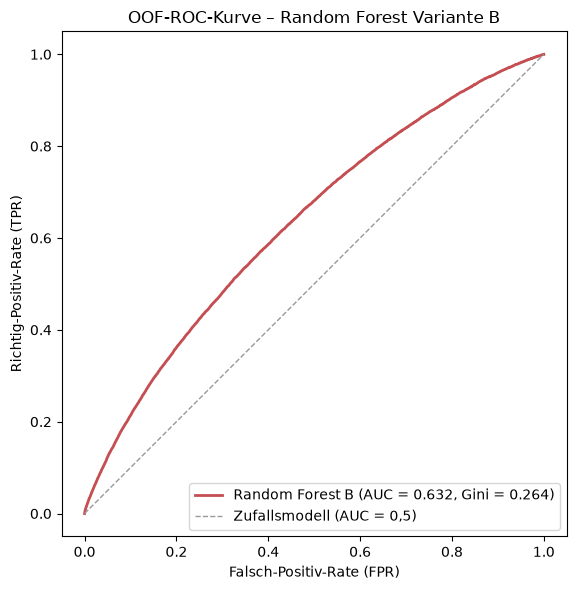

In [16]:
# Visualisierung der OOF-ROC-Kurve

fpr_b, tpr_b, _ = roc_curve(y, oof_proba_b)

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(
    fpr_b,
    tpr_b,
    color="#C44E52",
    linewidth=2,
    label=(
        f"Random Forest B "
        f"(AUC = {oof_auc_b:.3f}, Gini = {oof_gini_b:.3f})"
    )
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#999999",
    linewidth=1,
    label="Zufallsmodell (AUC = 0,5)"
)

ax.set_xlabel("Falsch-Positiv-Rate (FPR)")
ax.set_ylabel("Richtig-Positiv-Rate (TPR)")
ax.set_title("OOF-ROC-Kurve – Random Forest Variante B")
ax.legend(loc="lower right")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()